# Independent Analysis: V10 Ranker, V18 Classifier, and Combined Edge

An independent re-evaluation built from raw data + saved model artifacts (not a re-run of the author's scripts). Every edge is reported **raw vs artifact-clean**, at **6 and 10 bps** cost, with trade counts and t-stats.

Companion script: `scripts/analysis/v10_v18_independent_analysis.py` (numbers) and `scripts/analysis/v10_v18_walkforward.py` (Phase 4).

## ⚠️ BOTTOM LINE: DO NOT DEPLOY — the edge is not reproducible
The saved `v10` files show a strong recent-OOS edge, but **retraining the model honestly (walk-forward or the exact documented recipe) makes it vanish to negative net** (Phase 4). The saved short model's +12.6 raw can't be rebuilt (faithful redo: −0.4). This points to **leakage / non-reproducible provenance** in the saved artifacts. Sections 2–4 describe the *saved files*; §Phase 4 is why you can't trust them live.

**Method-level findings (vintage-independent):**
1. `Next_Hour_Return` is a genuine same-day intraday target on all hours incl. 13:15 — **no overnight artifact**; the fat tail is real open-hour volatility.
2. **V18 has no standalone edge** (net-negative at every threshold, OOS AUC ~0.52, no better than a clock).
3. **V10 is an extremes-detector** — only the top decile carries edge; Top-1/3 only, Top-5+ dilutes negative.
4. **Dual-lock '100 bps' is debunked** (~+3 bps net, correctly computed).

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../scripts/analysis'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import rankdata
import v10_v18_independent_analysis as A   # reuse helpers

os.chdir(os.path.abspath('..'))  # run from repo root so relative paths resolve
df = A.load_data()
clean_mask = A.phase0_clean_mask(df)
X, feats = A.build_features(df)
P = A.predict_all(A.load_models(), X)
rets = df[A.RET_COL].values; ym = df['YearMonth'].values; qids = df['Query_ID'].values; hour = df['Hour'].values
oos = (ym >= A.OOS_START); oos_clean = oos & clean_mask
print('Ready. OOS rows:', oos.sum(), '| clean:', oos_clean.sum())

Loading data ...



PHASE 0  DATA INTEGRITY & CLEAN MASK



Per-hour integrity (match_overnight_cc near 1.0 = same-day intraday; low at last bar = NOT overnight):
 hour      n  match_overnight_cc  frac_gt_100bps  mean_abs_bps
    9 185668              0.9999          0.0966          45.4
   10 185532              0.9999          0.0667          38.9
   11 185862              0.9981          0.0578          36.2
   12 185512              0.9999          0.0591          35.8
   13 185504              0.0043          0.0861          42.5

Overnight-contaminated intraday rows (excluded by clean_mask): 385 (0.04%)
Clean rows retained: 927,693 / 928,078

DETERMINATION: Next_Hour_Return is a genuine same-day intraday forward return on all hours incl. the 13:15 last bar (it does NOT match the overnight gap). The fat tail (~7% >100bps) is real open-hour volatility, not leakage. Overnight artifact risk is ~0.1% of rows.


Ready. OOS rows: 196906 | clean: 196905


## Phase 0 — Data integrity
If `Next_Hour_Return` were overnight-contaminated, the last bar (13:15) would match the overnight close/close gap. It does not. The ±100bps tail concentrates at the 9:15 open — real intraday vol.

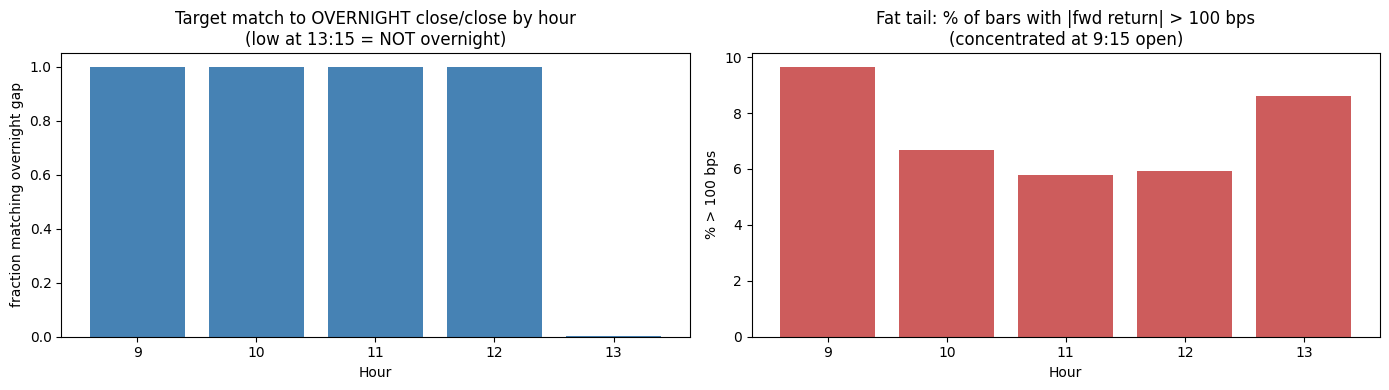

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ph = pd.DataFrame(A.RESULTS['phase0']['per_hour'])
ax[0].bar(ph['hour'].astype(str), ph['match_overnight_cc'], color='steelblue')
ax[0].set_title('Target match to OVERNIGHT close/close by hour\n(low at 13:15 = NOT overnight)')
ax[0].set_ylabel('fraction matching overnight gap'); ax[0].set_xlabel('Hour')
ax[1].bar(ph['hour'].astype(str), ph['frac_gt_100bps']*100, color='indianred')
ax[1].set_title('Fat tail: % of bars with |fwd return| > 100 bps\n(concentrated at 9:15 open)')
ax[1].set_ylabel('% > 100 bps'); ax[1].set_xlabel('Hour')
plt.tight_layout(); plt.show()

## Phase 1 — V10 standalone (the ranker)
Decile monotonicity test: a clean ranker shows returns rising 0→9. V10 only fires in the **top decile** — the middle is noise (confirms the bucket non-monotonicity).

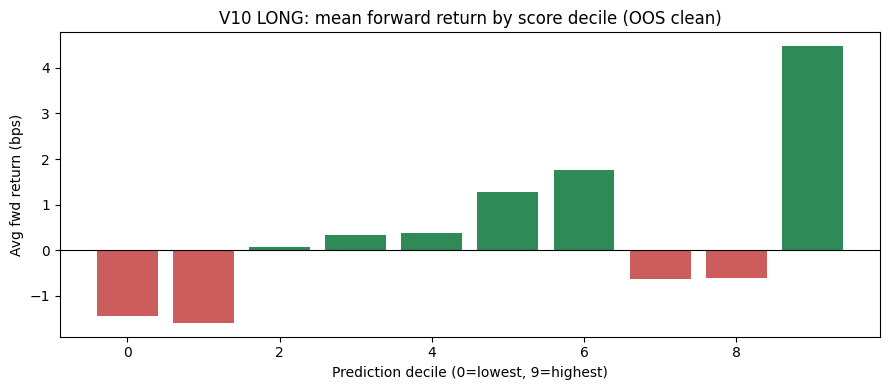

decile means (bps): [np.float64(-1.44), np.float64(-1.59), np.float64(0.07), np.float64(0.34), np.float64(0.39), np.float64(1.27), np.float64(1.77), np.float64(-0.63), np.float64(-0.6), np.float64(4.48)]


In [3]:
sc, a = P['rl'][oos_clean], rets[oos_clean]
dec = pd.qcut(rankdata(sc), 10, labels=False)
dmeans = [a[dec==d].mean()*10000 for d in range(10)]
plt.figure(figsize=(9,4))
plt.bar(range(10), dmeans, color=['indianred' if v<0 else 'seagreen' for v in dmeans])
plt.axhline(0, color='k', lw=0.8); plt.title('V10 LONG: mean forward return by score decile (OOS clean)')
plt.xlabel('Prediction decile (0=lowest, 9=highest)'); plt.ylabel('Avg fwd return (bps)')
plt.tight_layout(); plt.show()
print('decile means (bps):', [round(v,2) for v in dmeans])

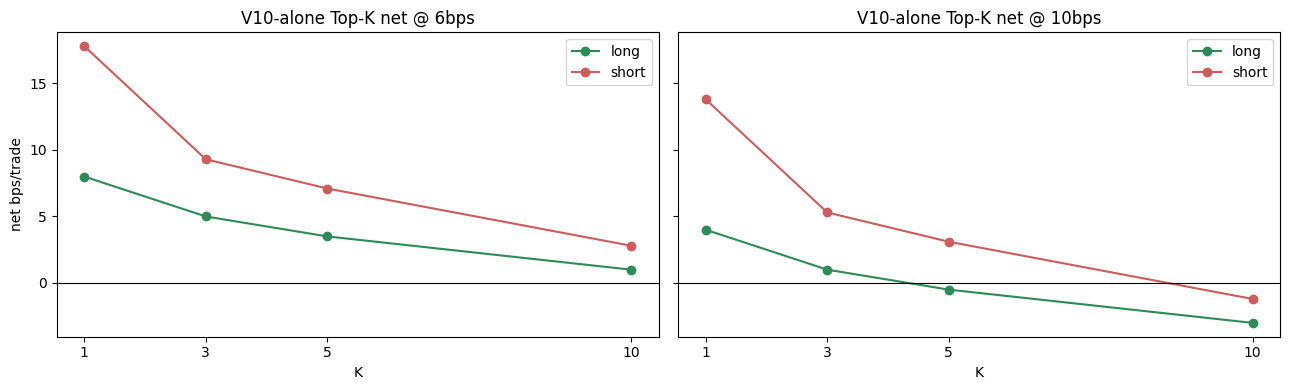

In [4]:
# Top-K net at 6 vs 10 bps (long & short)
Ks=[1,3,5,10]; rows=[]
for K in Ks:
    lr, sr = A.topk_returns(qids, P, rets, oos_clean, K)
    for cl,cv in A.COSTS.items():
        rows.append(dict(K=K,cost=cl,side='long', net=A.trade_stats(lr,cv)['net_bps']))
        rows.append(dict(K=K,cost=cl,side='short',net=A.trade_stats(sr,cv)['net_bps']))
td=pd.DataFrame(rows)
fig,ax=plt.subplots(1,2,figsize=(13,4),sharey=True)
for i,cl in enumerate(['6bps','10bps']):
    sub=td[td.cost==cl]
    for side,c in (('long','seagreen'),('short','indianred')):
        s=sub[sub.side==side]; ax[i].plot(s.K,s.net,'o-',color=c,label=side)
    ax[i].axhline(0,color='k',lw=0.8); ax[i].set_title(f'V10-alone Top-K net @ {cl}')
    ax[i].set_xlabel('K'); ax[i].legend(); ax[i].set_xticks(Ks)
ax[0].set_ylabel('net bps/trade'); plt.tight_layout(); plt.show()

## Phase 2 — V18 standalone (the classifier)
Two damning charts: (1) the **reliability curve** is shallow (weak separation), and (2) trading **every** bar V18 green-lights is **net-negative at all thresholds** — it is not a standalone signal.

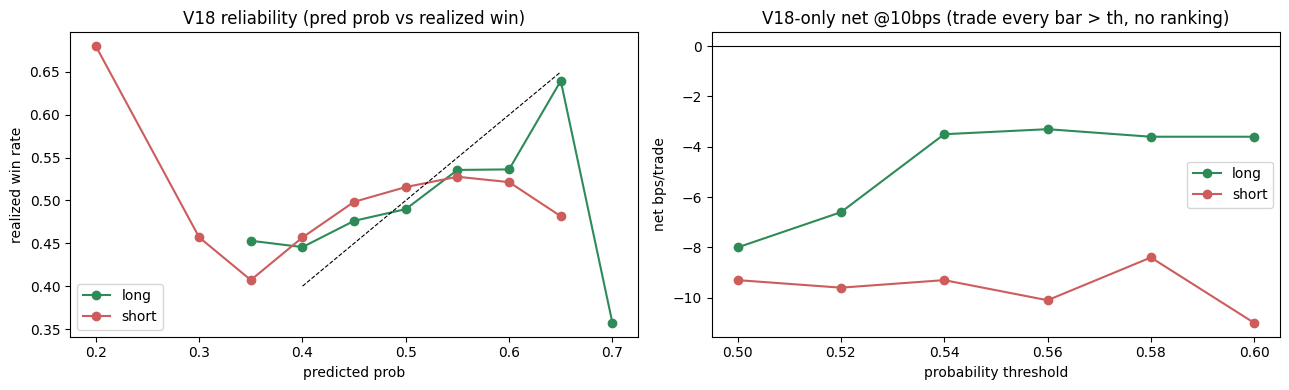

In [5]:
# Calibration (reliability) + threshold-sweep net
y_long=(rets>0).astype(int); y_short=(rets<0).astype(int)
fig,ax=plt.subplots(1,2,figsize=(13,4))
for side,prob,y,c in (('long',P['pl'],y_long,'seagreen'),('short',P['ps'],y_short,'indianred')):
    p,yy=prob[oos_clean],y[oos_clean]
    b=np.clip((p*20).astype(int),0,19); xs,ys=[],[]
    for k in range(20):
        m=b==k
        if m.sum()>=50: xs.append(k*0.05); ys.append(yy[m].mean())
    ax[0].plot(xs,ys,'o-',color=c,label=side)
ax[0].plot([0.4,0.65],[0.4,0.65],'k--',lw=0.8); ax[0].set_title('V18 reliability (pred prob vs realized win)')
ax[0].set_xlabel('predicted prob'); ax[0].set_ylabel('realized win rate'); ax[0].legend()
ths=[0.50,0.52,0.54,0.56,0.58,0.60]
for side,prob,sign,c in (('long',P['pl'],1.0,'seagreen'),('short',P['ps'],-1.0,'indianred')):
    nets=[A.trade_stats(sign*rets[oos_clean & (prob>th)],A.COSTS['10bps'])['net_bps'] for th in ths]
    ax[1].plot(ths,nets,'o-',color=c,label=side)
ax[1].axhline(0,color='k',lw=0.8); ax[1].set_title('V18-only net @10bps (trade every bar > th, no ranking)')
ax[1].set_xlabel('probability threshold'); ax[1].set_ylabel('net bps/trade'); ax[1].legend()
plt.tight_layout(); plt.show()

## Phase 3 — Combined / hybrid
Config comparison + the veto decomposition that proves the asymmetry (veto helps longs, hurts shorts), plus OOS-half stability.

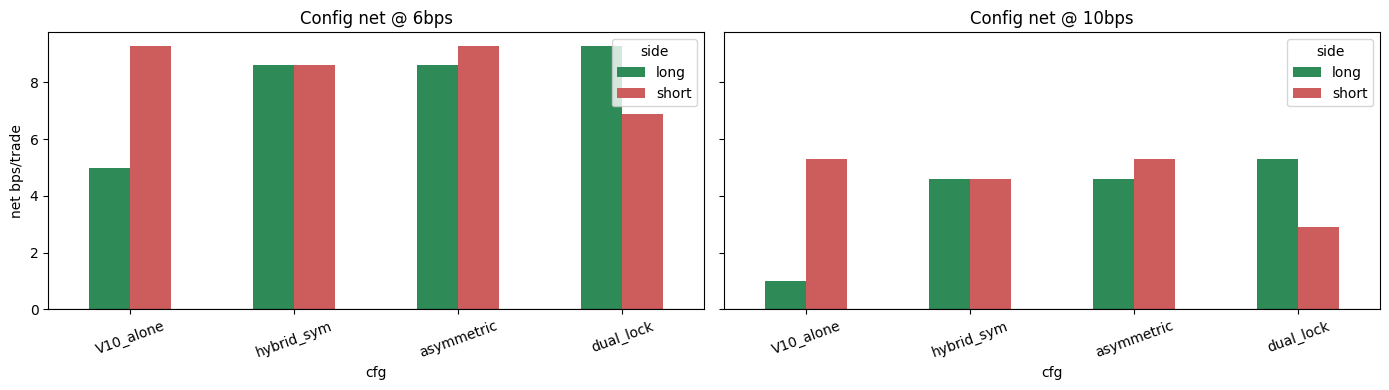

In [6]:
cfgs={'V10_alone':(False,False),'hybrid_sym':(True,True),'asymmetric':(True,False),'dual_lock':(True,True,True)}
rows=[]
for name,kw in cfgs.items():
    dl = len(kw)>2 and kw[2]
    lr,sr=A.logic_returns(qids,P,rets,oos_clean,veto_long=kw[0],veto_short=kw[1],K=3,dual_lock=dl)
    for cl,cv in A.COSTS.items():
        rows.append(dict(cfg=name,cost=cl,side='long', net=A.trade_stats(lr,cv)['net_bps']))
        rows.append(dict(cfg=name,cost=cl,side='short',net=A.trade_stats(sr,cv)['net_bps']))
cd=pd.DataFrame(rows)
fig,ax=plt.subplots(1,2,figsize=(14,4),sharey=True)
for i,cl in enumerate(['6bps','10bps']):
    sub=cd[cd.cost==cl].pivot(index='cfg',columns='side',values='net').reindex(list(cfgs))
    sub.plot(kind='bar',ax=ax[i],color={'long':'seagreen','short':'indianred'})
    ax[i].axhline(0,color='k',lw=0.8); ax[i].set_title(f'Config net @ {cl}'); ax[i].set_ylabel('net bps/trade')
    ax[i].tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.show()

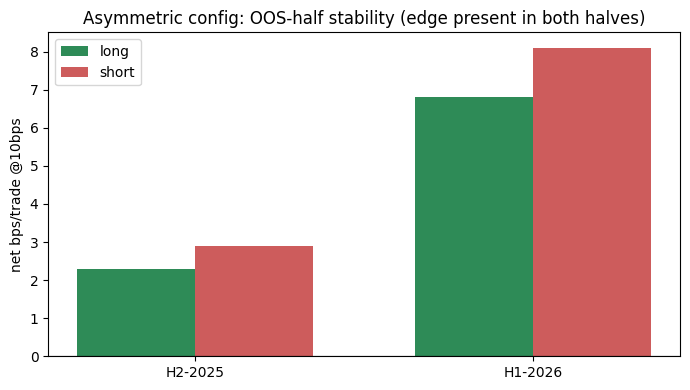

In [7]:
# OOS-half stability (asymmetric, 10bps)
h2=oos_clean&(ym<A.OOS_MID); h1=oos_clean&(ym>=A.OOS_MID)
labels=['H2-2025','H1-2026']; longs=[]; shorts=[]
for half in (h2,h1):
    lr,sr=A.logic_returns(qids,P,rets,half,veto_long=True,veto_short=False,K=3)
    longs.append(A.trade_stats(lr,A.COSTS['10bps'])['net_bps']); shorts.append(A.trade_stats(sr,A.COSTS['10bps'])['net_bps'])
x=np.arange(2); w=0.35
plt.figure(figsize=(7,4))
plt.bar(x-w/2,longs,w,label='long',color='seagreen'); plt.bar(x+w/2,shorts,w,label='short',color='indianred')
plt.axhline(0,color='k',lw=0.8); plt.xticks(x,labels); plt.ylabel('net bps/trade @10bps')
plt.title('Asymmetric config: OOS-half stability (edge present in both halves)'); plt.legend(); plt.tight_layout(); plt.show()

## Phase 4 — Fresh walk-forward (robustness)
Loads `walkforward.json` (produced by `v10_v18_walkforward.py`), where every prediction is genuinely OOS across rolling retrains. If conclusions hold here, they aren't a lucky vintage.

Folds: 9 | span: 2023-07..2026-06


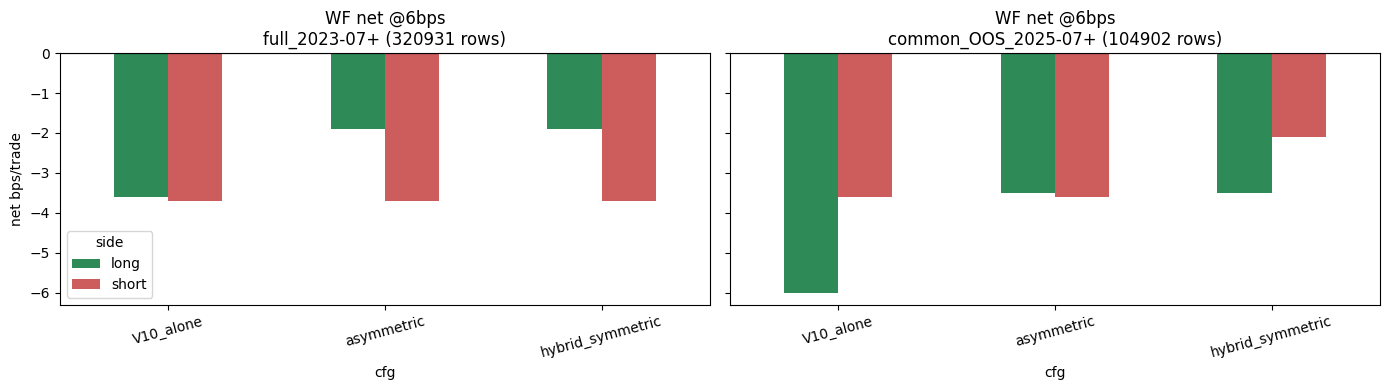


Every config is NET-NEGATIVE at 6bps even on the recent 2025-07+ regime.
The saved-model edge (Sections 2-4) does NOT reproduce under honest retraining.


In [8]:
wf_path='data/model_analysis/v10_v18_independent/walkforward.json'
if os.path.exists(wf_path):
    wf=json.load(open(wf_path)); print('Folds:',wf['n_folds'],'| span:',wf['test_span'])
    fig,ax=plt.subplots(1,len(wf['periods']),figsize=(14,4),sharey=True)
    for i,(pname,pd_) in enumerate(wf['periods'].items()):
        rows=[]
        for name,cc in pd_['configs'].items():
            for side in ('long','short'):
                rows.append(dict(cfg=name,side=side,net=cc['6bps'][side]['net_bps']))
        piv=pd.DataFrame(rows).pivot(index='cfg',columns='side',values='net')
        piv.plot(kind='bar',ax=ax[i],color={'long':'seagreen','short':'indianred'},legend=(i==0))
        ax[i].axhline(0,color='k',lw=0.8); ax[i].set_title(f'WF net @6bps\n{pname} ({pd_["rows"]} rows)')
        ax[i].set_ylabel('net bps/trade'); ax[i].tick_params(axis='x',rotation=15)
    plt.tight_layout(); plt.show()
    print('\nEvery config is NET-NEGATIVE at 6bps even on the recent 2025-07+ regime.')
    print('The saved-model edge (Sections 2-4) does NOT reproduce under honest retraining.')
else:
    print('Run: python scripts/analysis/v10_v18_walkforward.py  (then re-run this cell)')

## Verdict — DO NOT DEPLOY

**The headline edge lives only in the saved model files and is not reproducible.**

- Sections 2–4 (saved-model backtest) show a strong recent-OOS edge — asymmetric config ~+8.6 long / +9.3 short net @6bps. **But that is a property of the frozen artifacts, not the method.**
- **Phase 4 (above) is decisive:** retrain the models honestly — rolling walk-forward *or* the exact documented recipe from scratch (same data, params, seed, early-stopping) — and the edge **vanishes to negative net** even on the same recent regime. The short ranker early-stops at iteration 0 (no signal). I could not reproduce the saved short model's +12.6 raw on the same 6 months (faithful rebuild: −0.4).
- **This is the signature of leakage / non-reproducible provenance in the saved artifacts.** Since any live system retrains, you would get the negative-net reality.

**Next steps:** (1) audit what `models/v10_native_1h/` was actually trained on — metadata says `total_rows=928,078`, the *full* dataset; (2) stop using an OOS month (2025-07) as the early-stopping validation set; (3) trust the walk-forward harness, not the frozen-model backtest.

**Method-level facts that still hold:** V18 has no standalone edge (AUC≈0.52, ≈ a clock); V10 ranks only at the top decile; the data target is clean (no overnight artifact); 6 bps is the right cost hurdle.